# ESM2 — DNA Binding Prediction (Clean Pipeline)

Binary classification: **DNA-binding** vs **non-DNA-binding** proteins  
Model: **ESM2** (1280-dim pooled embeddings)  
Classifiers: Logistic Regression + MLP  
Extra: DNA-binding domain 21-mer window analysis using per-residue embeddings  
Output: `results_dna_ESM2/interpretation_report.html`

In [ ]:
# ============================================================
# Cell 2 — Imports, SEED, device
# ============================================================
import random, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import umap as umap_lib
import base64

from pathlib import Path
from typing import Optional

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, roc_curve, auc,
    precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay, matthews_corrcoef,
    precision_score, recall_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Explicit plot style — consistent with Ankh / ProtT5 pipeline ─────────────
mpl.rcParams.update({
    "figure.dpi"        : 110,
    "savefig.dpi"       : 300,
    "font.size"         : 11,
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 12,
    "xtick.labelsize"   : 11,
    "ytick.labelsize"   : 11,
    "legend.fontsize"   : 10,
    "figure.titlesize"  : 14,
    "axes.spines.top"   : True,
    "axes.spines.right" : True,
    "axes.grid"         : False,
    "font.family"       : "DejaVu Sans",
})

print("Device:", device)

Device: cuda


In [2]:
# ============================================================
# Cell 3 — Path resolution
# ============================================================
PROJECT_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path.cwd()
RESULTS_DIR = PROJECT_DIR / "results_dna_ESM2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ESM2 embeddings are on NFS only
NFS_ROOT    = Path("/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref")
LOCAL_ROOT  = PROJECT_DIR.parent.parent / "all_uniref"

CSV_FILE    = LOCAL_ROOT / "uniprotkb_AND_reviewed_true_AND_model_o_2026_01_16.tsv"
EMBED_FILE  = NFS_ROOT   / "esm2_embedding_cache" / "pooled_embeddings.npz"
RESIDUE_DIR = NFS_ROOT   / "esm2_embedding_cache"

print(f"Project dir  : {PROJECT_DIR}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"CSV file     : {CSV_FILE}  (exists: {CSV_FILE.exists()})")
print(f"Embedding    : {EMBED_FILE}  (exists: {EMBED_FILE.exists()})")
print(f"Residue dir  : {RESIDUE_DIR}  (exists: {RESIDUE_DIR.exists()})")

Project dir  : /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction
Results dir  : /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2
CSV file     : /home/saishyam/Protein_dynamics/all_uniref/uniprotkb_AND_reviewed_true_AND_model_o_2026_01_16.tsv  (exists: True)
Embedding    : /nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/esm2_embedding_cache/pooled_embeddings.npz  (exists: True)
Residue dir  : /nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/esm2_embedding_cache  (exists: True)


In [3]:
# ============================================================
# Cell 4 — Load CSV + build DNA-binding labels
# ============================================================
raw_df = pd.read_csv(CSV_FILE, sep="\t", low_memory=False)
print(f"Loaded {len(raw_df):,} rows from CSV")

# ---- Split DNA-binding (pos) / non-DNA-binding (neg) ----
pos_df = raw_df[raw_df["DNA binding"].notna()].copy()
neg_df = raw_df[raw_df["DNA binding"].isna()].copy()

pos_df = pos_df[["Entry", "Protein names", "Sequence", "DNA binding"]].rename(
    columns={"Entry": "protein_id", "Protein names": "protein_name", "Sequence": "sequence"})
neg_df = neg_df[["Entry", "Protein names", "Sequence"]].rename(
    columns={"Entry": "protein_id", "Protein names": "protein_name", "Sequence": "sequence"})

pos_df = pos_df.drop_duplicates(subset="protein_name", keep="first")
neg_df = neg_df.drop_duplicates(subset="protein_name", keep="first")
overlap = set(pos_df["protein_name"]) & set(neg_df["protein_name"])
pos_df = pos_df[~pos_df["protein_name"].isin(overlap)].reset_index(drop=True)
neg_df = neg_df[~neg_df["protein_name"].isin(overlap)].reset_index(drop=True)

pos_df["label"] = 1
neg_df["label"] = 0

all_df = pd.concat([pos_df[["protein_id","protein_name","sequence","label"]],
                    neg_df[["protein_id","protein_name","sequence","label"]]], ignore_index=True)

assert pos_df["protein_name"].is_unique
assert neg_df["protein_name"].is_unique
assert set(pos_df["protein_name"]).isdisjoint(set(neg_df["protein_name"]))

print(f"DNA-binding (pos) : {len(pos_df):,}")
print(f"Non-DNA-binding   : {len(neg_df):,}")
print(f"Imbalance ratio   : 1 : {len(neg_df)/len(pos_df):.1f}")
display(all_df["label"].value_counts().rename({1: "DNA-binding", 0: "Non-DNA-binding"}).rename("count").to_frame())

Loaded 18,459 rows from CSV
DNA-binding (pos) : 572
Non-DNA-binding   : 17,887
Imbalance ratio   : 1 : 31.3


,count
label,
Non-DNA-binding,17887
DNA-binding,572


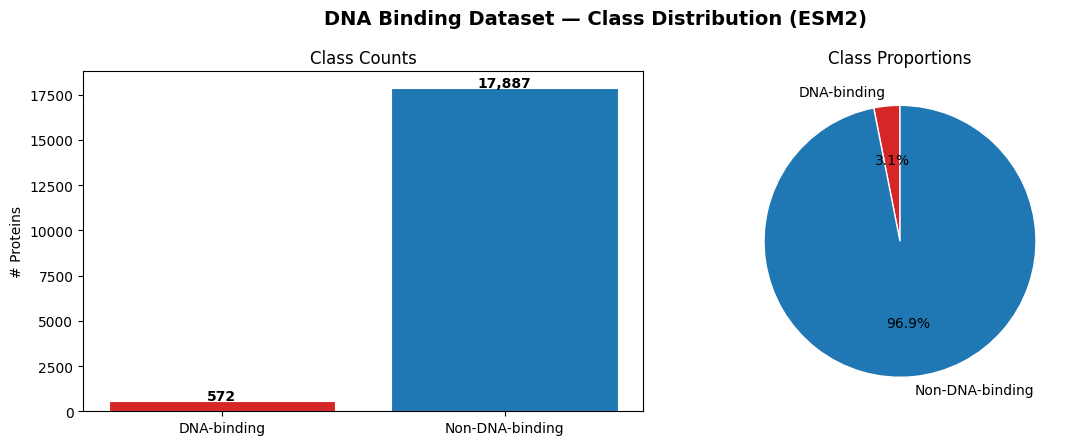

Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/class_distribution.png


In [4]:
# ============================================================
# Cell 5 — Class distribution & imbalance visualisation
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

counts = [len(pos_df), len(neg_df)]
labels = ["DNA-binding", "Non-DNA-binding"]
colors = ["#d62728", "#1f77b4"]
axes[0].bar(labels, counts, color=colors, edgecolor="white", linewidth=0.8)
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")
axes[0].set_ylabel("# Proteins")
axes[0].set_title("Class Counts")

axes[1].pie(counts, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Class Proportions")

plt.suptitle("DNA Binding Dataset — Class Distribution (ESM2)", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_dist = RESULTS_DIR / "class_distribution.png"
plt.savefig(fig_dist, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_dist}")

In [5]:
# ============================================================
# Cell 6 — Load pooled ESM2 embeddings
# ============================================================
print(f"Loading ESM2 embeddings from: {EMBED_FILE}")
t0 = time.perf_counter()
cache     = np.load(EMBED_FILE, allow_pickle=True)
max_pool  = cache["max"].item()   # dict: protein_id → ndarray (1280,)
attn_pool = cache["attn"].item()  # dict: protein_id → ndarray (1280,)
print(f"Loaded in {time.perf_counter()-t0:.1f}s")

def collect_embeddings(df, pool_dict):
    X, ids, labs = [], [], []
    miss = 0
    for _, row in df.iterrows():
        pid = row["protein_id"]
        if pid in pool_dict:
            X.append(pool_dict[pid])
            ids.append(pid)
            labs.append(row["label"])
        else:
            miss += 1
    if miss > 0:
        print(f"  Missing embeddings: {miss} proteins skipped")
    return np.stack(X).astype(np.float32), ids, np.array(labs)

X_max_pos,  _, _ = collect_embeddings(pos_df.assign(label=1), max_pool)
X_max_neg,  _, _ = collect_embeddings(neg_df.assign(label=0), max_pool)
X_attn_pos, _, _ = collect_embeddings(pos_df.assign(label=1), attn_pool)
X_attn_neg, _, _ = collect_embeddings(neg_df.assign(label=0), attn_pool)

emb_dim = X_max_pos.shape[1]
assert emb_dim == 1280, f"Expected 1280-dim, got {emb_dim}"

X_max  = np.vstack([X_max_pos,  X_max_neg])
X_attn = np.vstack([X_attn_pos, X_attn_neg])
y_bin  = np.array([1]*len(X_max_pos) + [0]*len(X_max_neg))

print(f"Max-pool   shape : {X_max.shape}")
print(f"Attn-pool  shape : {X_attn.shape}")
print(f"Labels     shape : {y_bin.shape}  |  positives: {y_bin.sum():,}  negatives: {(1-y_bin).sum():,}")
print(f"Embedding dim    : {emb_dim}")

Loading ESM2 embeddings from: /nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/esm2_embedding_cache/pooled_embeddings.npz
Loaded in 1.7s
Max-pool   shape : (18459, 1280)
Attn-pool  shape : (18459, 1280)
Labels     shape : (18459,)  |  positives: 572  negatives: 17,887
Embedding dim    : 1280


In [6]:
# ============================================================
# Cell 7 — make_split / evaluate helpers + Logistic Regression
# ============================================================

def make_split(X, y):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED
    )
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr).astype(np.float32)
    Xte = sc.transform(Xte).astype(np.float32)
    return Xtr, Xte, ytr, yte, sc


def evaluate_binary(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    roc    = roc_auc_score(y_true, y_pred_proba)
    pr     = average_precision_score(y_true, y_pred_proba)
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    mcc    = matthews_corrcoef(y_true, y_pred)
    fpr, tpr, _     = roc_curve(y_true, y_pred_proba)
    pre_c, rec_c, _ = precision_recall_curve(y_true, y_pred_proba)
    return dict(
        roc_auc=roc, pr_auc=pr, accuracy=acc, f1=f1,
        precision=prec, recall=rec, mcc=mcc,
        fpr=fpr, tpr=tpr, pre_c=pre_c, rec_c=rec_c,
        y_pred=y_pred, y_true=y_true, y_proba=y_pred_proba,
        n_test=len(y_true),
    )


results_store = {}
t0 = time.perf_counter()

for pool_name, X in [("max", X_max), ("attn", X_attn)]:
    Xtr, Xte, ytr, yte, _ = make_split(X, y_bin)
    clf = LogisticRegression(max_iter=5000, class_weight="balanced", n_jobs=-1, random_state=SEED)
    clf.fit(Xtr, ytr)
    proba = clf.predict_proba(Xte)[:, 1]
    results_store[("logistic_regression", pool_name)] = evaluate_binary(yte, proba)
    print(f"LR | {pool_name:4s} → ROC-AUC={results_store[('logistic_regression',pool_name)]['roc_auc']:.4f}  "
          f"PR-AUC={results_store[('logistic_regression',pool_name)]['pr_auc']:.4f}  "
          f"F1={results_store[('logistic_regression',pool_name)]['f1']:.4f}  "
          f"MCC={results_store[('logistic_regression',pool_name)]['mcc']:.4f}")

print(f"\nLogistic Regression complete in {time.perf_counter()-t0:.1f}s")

LR | max  → ROC-AUC=0.9445  PR-AUC=0.8753  F1=0.8362  MCC=0.8310
LR | attn → ROC-AUC=0.9733  PR-AUC=0.8930  F1=0.8511  MCC=0.8466

Logistic Regression complete in 9.2s


In [7]:
# ============================================================
# Cell 8 — MLP (binary) + training
# ============================================================

class MLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


training_loss = {}


def train_mlp(X: np.ndarray, y: np.ndarray, epochs=30, lr=1e-3, batch=64):
    Xtr, Xte, ytr, yte, sc = make_split(X, y)
    ytr_f = ytr.astype(np.float32)

    n_pos = ytr_f.sum(); n_neg = len(ytr_f) - n_pos
    pos_weight = torch.tensor(n_neg / max(n_pos, 1), dtype=torch.float32).to(device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model_m   = MLP(X.shape[1]).to(device)
    optimizer = torch.optim.Adam(model_m.parameters(), lr=lr)
    loader    = DataLoader(
        TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr_f)),
        batch_size=batch, shuffle=True,
    )

    losses = []
    model_m.train()
    for epoch in range(epochs):
        running = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model_m(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item()
        losses.append(running / len(loader))

    model_m.eval()
    with torch.no_grad():
        proba = torch.sigmoid(
            model_m(torch.from_numpy(Xte).to(device))
        ).cpu().numpy()

    return evaluate_binary(yte, proba), losses


t0 = time.perf_counter()
for pool_name, X in [("max", X_max), ("attn", X_attn)]:
    metrics, losses = train_mlp(X, y_bin)
    results_store[("mlp", pool_name)] = metrics
    training_loss[pool_name] = losses
    print(f"MLP | {pool_name:4s} → ROC-AUC={metrics['roc_auc']:.4f}  "
          f"PR-AUC={metrics['pr_auc']:.4f}  "
          f"F1={metrics['f1']:.4f}  "
          f"MCC={metrics['mcc']:.4f}")

print(f"\nMLP training complete in {time.perf_counter()-t0:.1f}s")

MLP | max  → ROC-AUC=0.9435  PR-AUC=0.8672  F1=0.7067  MCC=0.7101
MLP | attn → ROC-AUC=0.9724  PR-AUC=0.8458  F1=0.6452  MCC=0.6561

MLP training complete in 21.3s


In [8]:
# ============================================================
# Cell 9 — Results DataFrame + save CSV/MD
# ============================================================

rows = []
for (model_name, pool_name), m in results_store.items():
    rows.append(dict(
        model=model_name, pooling=pool_name,
        roc_auc=round(m["roc_auc"],   4),
        pr_auc=round(m["pr_auc"],     4),
        f1=round(m["f1"],             4),
        accuracy=round(m["accuracy"], 4),
        mcc=round(m["mcc"],           4),
        precision=round(m["precision"], 4),
        recall=round(m["recall"],     4),
        n_test=m["n_test"],
    ))

results_df = (
    pd.DataFrame(rows)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

results_df.to_csv(RESULTS_DIR / "summary_metrics.csv", index=False)
results_df.to_markdown(RESULTS_DIR / "summary_metrics.md", index=False)

print(f"Saved: {RESULTS_DIR}/summary_metrics.csv")
print(f"Saved: {RESULTS_DIR}/summary_metrics.md")

display(
    results_df.style
    .highlight_max(subset=["roc_auc","pr_auc","f1","mcc"], color="#d4f0c4")
    .format({c: "{:.4f}" for c in ["roc_auc","pr_auc","f1","accuracy","mcc","precision","recall"]})
)

Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/summary_metrics.csv
Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/summary_metrics.md


,model,pooling,roc_auc,pr_auc,f1,accuracy,mcc,precision,recall,n_test
0,logistic_regression,attn,0.9733,0.8930,0.8511,0.9905,0.8466,0.8264,0.8772,3692
1,mlp,attn,0.9724,0.8458,0.6452,0.9702,0.6561,0.5102,0.8772,3692
2,logistic_regression,max,0.9445,0.8753,0.8362,0.9897,0.8310,0.8220,0.8509,3692
3,mlp,max,0.9435,0.8672,0.7067,0.9775,0.7101,0.5917,0.8772,3692


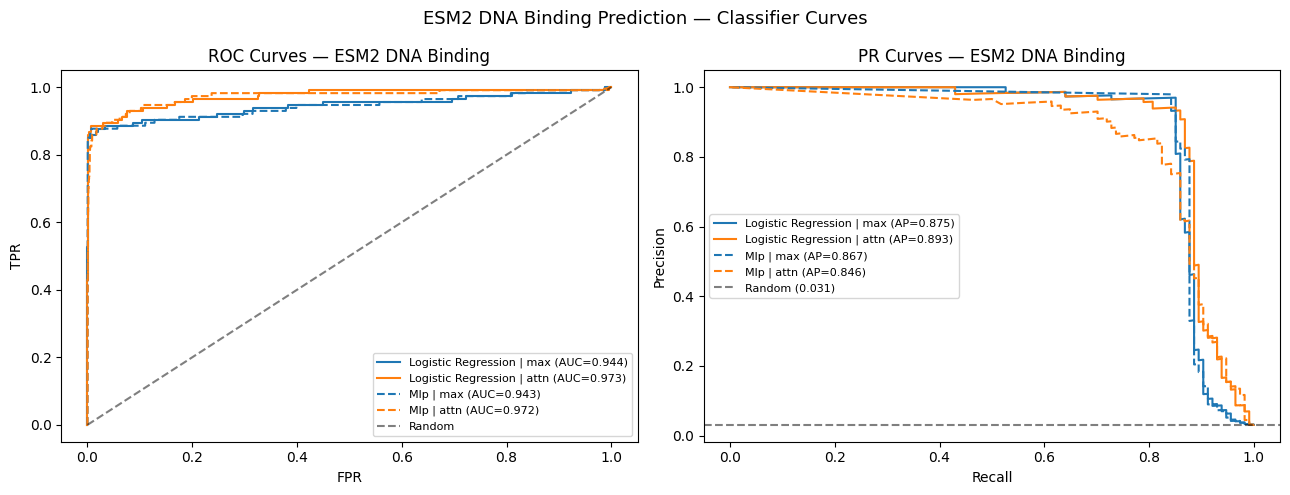

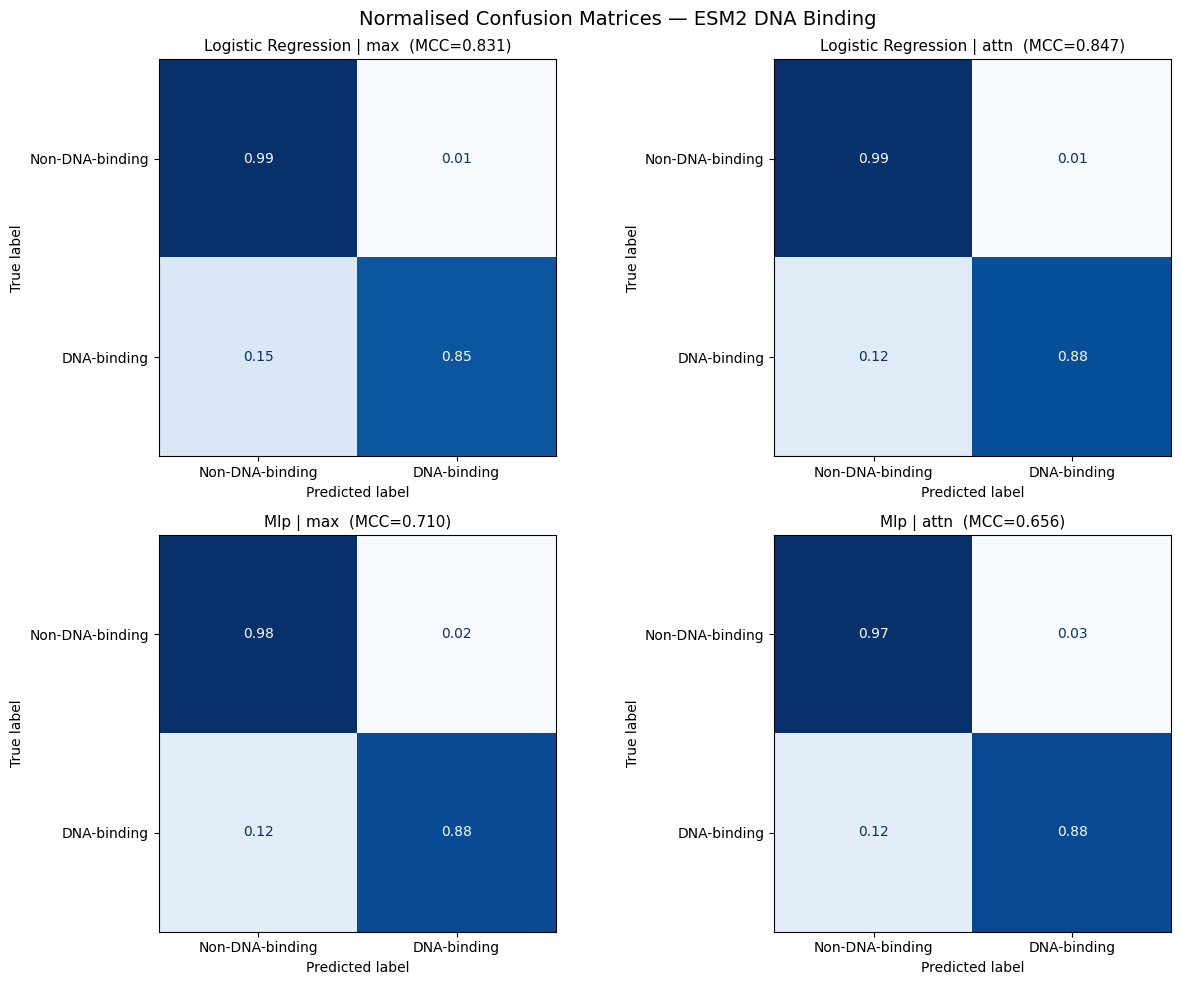

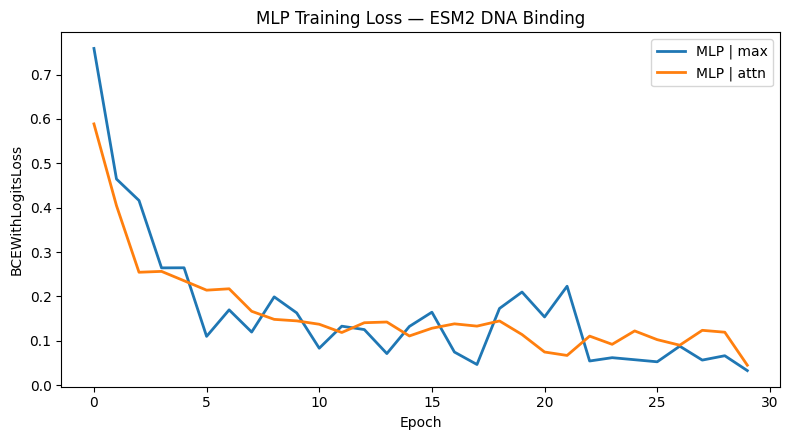

Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/roc_pr_curves.png
Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/confusion_matrices.png
Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/mlp_training_loss.png


In [9]:
# ============================================================
# Cell 10 — ROC, PR curves, confusion matrices, MLP loss
# ============================================================

best_row = results_df.iloc[0]
best_key = (best_row["model"], best_row["pooling"])

# ---- ROC + PR curves ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_cfg = {"max": "#1f77b4", "attn": "#ff7f0e"}
styles_cfg = {"logistic_regression": "-", "mlp": "--"}

for (mn, pn), m in results_store.items():
    lbl = f"{mn.replace('_',' ').title()} | {pn} (AUC={m['roc_auc']:.3f})"
    axes[0].plot(m["fpr"], m["tpr"], linestyle=styles_cfg[mn],
                 color=colors_cfg[pn], label=lbl)
axes[0].plot([0,1],[0,1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves — ESM2 DNA Binding")
axes[0].legend(fontsize=8)

baseline = y_bin.mean()
for (mn, pn), m in results_store.items():
    lbl = f"{mn.replace('_',' ').title()} | {pn} (AP={m['pr_auc']:.3f})"
    axes[1].plot(m["rec_c"], m["pre_c"], linestyle=styles_cfg[mn],
                 color=colors_cfg[pn], label=lbl)
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.5, label=f"Random ({baseline:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curves — ESM2 DNA Binding")
axes[1].legend(fontsize=8)

plt.suptitle("ESM2 DNA Binding Prediction — Classifier Curves", fontsize=13)
plt.tight_layout()
roc_path = RESULTS_DIR / "roc_pr_curves.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight"); plt.show()

# ---- Confusion matrices ----
keys_order = [
    ("logistic_regression", "max"),  ("logistic_regression", "attn"),
    ("mlp",                 "max"),  ("mlp",                 "attn"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, key in zip(axes.ravel(), keys_order):
    m  = results_store[key]
    cm = confusion_matrix(m["y_true"], m["y_pred"], normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=["Non-DNA-binding","DNA-binding"]).plot(
        ax=ax, cmap="Blues", values_format=".2f", colorbar=False
    )
    ax.set_title(f"{key[0].replace('_',' ').title()} | {key[1]}  (MCC={results_store[key]['mcc']:.3f})", fontsize=11)

plt.suptitle("Normalised Confusion Matrices — ESM2 DNA Binding", fontsize=14)
plt.tight_layout()
cm_path = RESULTS_DIR / "confusion_matrices.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight"); plt.show()

# ---- MLP training loss ----
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(training_loss["max"],  label="MLP | max",  linewidth=2)
ax.plot(training_loss["attn"], label="MLP | attn", linewidth=2)
ax.set_title("MLP Training Loss — ESM2 DNA Binding")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCEWithLogitsLoss")
ax.legend(); plt.tight_layout()
loss_path = RESULTS_DIR / "mlp_training_loss.png"
plt.savefig(loss_path, dpi=300, bbox_inches="tight"); plt.show()

print(f"Saved: {roc_path}\nSaved: {cm_path}\nSaved: {loss_path}")

Visualising 5000 points (155 pos, 4845 neg)
t-SNE complete in 24.9s
UMAP complete in 24.7s


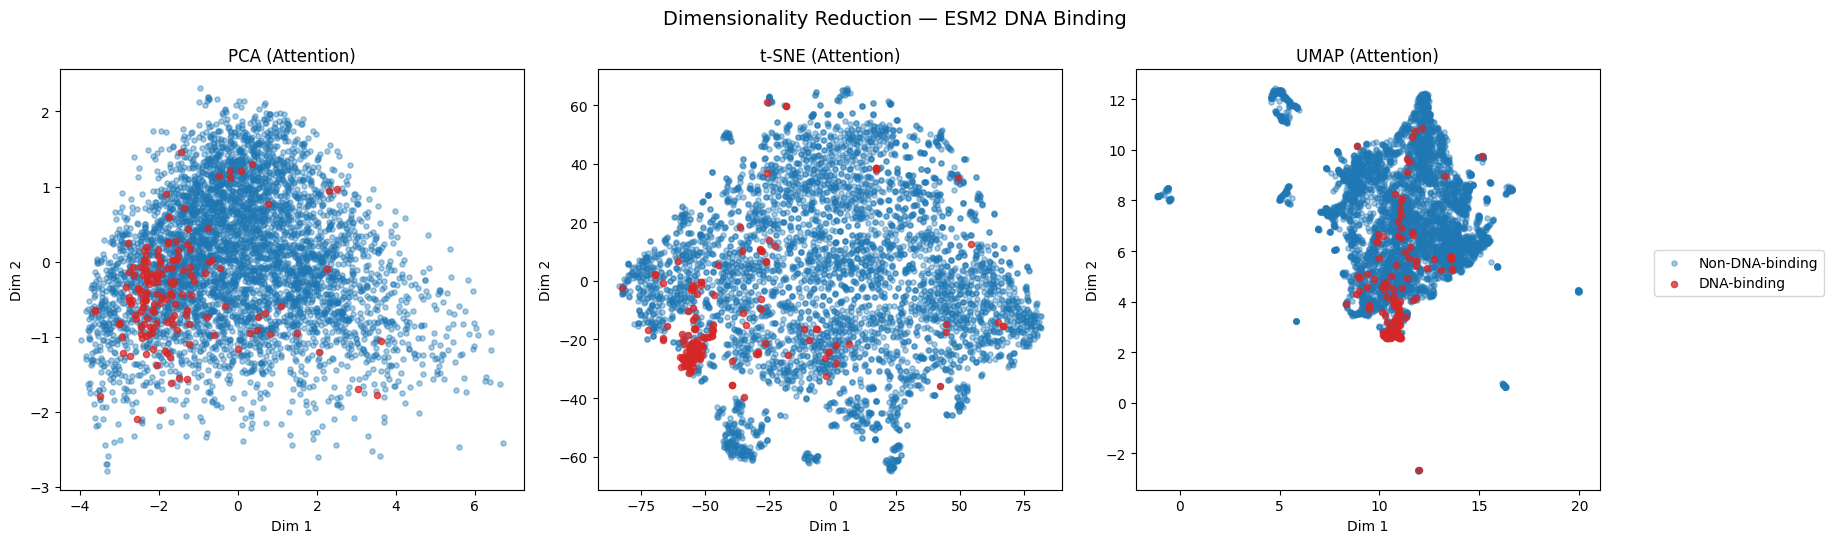

Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/embedding_projection_pca_tsne_umap.png


In [10]:
# ============================================================
# Cell 11 — PCA + t-SNE + UMAP visualisation
# ============================================================
MAX_VIS = 5000
if len(X_attn) > MAX_VIS:
    rng     = np.random.default_rng(SEED)
    idx_pos = np.where(y_bin == 1)[0]
    idx_neg = np.where(y_bin == 0)[0]
    n_pos_v = min(len(idx_pos), int(MAX_VIS * len(idx_pos) / len(y_bin)) + 1)
    n_neg_v = MAX_VIS - n_pos_v
    idx = np.concatenate([
        rng.choice(idx_pos, size=n_pos_v, replace=False),
        rng.choice(idx_neg, size=n_neg_v, replace=False),
    ])
    X_vis = X_attn[idx]; y_vis = y_bin[idx]
    print(f"Visualising {MAX_VIS} points ({n_pos_v} pos, {n_neg_v} neg)")
else:
    X_vis, y_vis = X_attn, y_bin
    print(f"Visualising full dataset: {len(X_vis)} points")

pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_vis)

t0 = time.perf_counter()
tsne_2d = TSNE(n_components=2, init="pca", learning_rate="auto",
               perplexity=30, random_state=SEED).fit_transform(X_vis)
print(f"t-SNE complete in {time.perf_counter()-t0:.1f}s")

t0 = time.perf_counter()
umap_2d = umap_lib.UMAP(n_neighbors=15, min_dist=0.1,
                         metric="cosine", random_state=SEED).fit_transform(X_vis)
print(f"UMAP complete in {time.perf_counter()-t0:.1f}s")

class_colors = {0: "#1f77b4", 1: "#d62728"}
class_labels = {0: "Non-DNA-binding", 1: "DNA-binding"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (title, emb) in zip(axes, [
    ("PCA (Attention)",   pca_2d),
    ("t-SNE (Attention)", tsne_2d),
    ("UMAP (Attention)",  umap_2d),
]):
    for cls in [0, 1]:
        mask = y_vis == cls
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   s=14 if cls == 0 else 20,
                   alpha=0.4 if cls == 0 else 0.75,
                   color=class_colors[cls], label=class_labels[cls],
                   zorder=1 if cls == 0 else 2)
    ax.set_title(title); ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")

handles, labs = axes[0].get_legend_handles_labels()
fig.legend(handles, labs, loc="center right", bbox_to_anchor=(1.02, 0.5), fontsize=10)
plt.suptitle("Dimensionality Reduction — ESM2 DNA Binding", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 1])
emb_path = RESULTS_DIR / "embedding_projection_pca_tsne_umap.png"
plt.savefig(emb_path, dpi=300, bbox_inches="tight"); plt.show()
print(f"Saved: {emb_path}")

In [11]:
# ============================================================
# Cell 12 — Analysis summary text file
# ============================================================
best_row = results_df.iloc[0]
summary_lines = [
    "ANALYSIS SUMMARY — ESM2 DNA Binding Prediction",
    "================================================",
    f"Best model by ROC-AUC: {best_row['model']} + {best_row['pooling']}",
    f"ROC-AUC   : {best_row['roc_auc']:.4f}",
    f"PR-AUC    : {best_row['pr_auc']:.4f}",
    f"F1 score  : {best_row['f1']:.4f}",
    f"Accuracy  : {best_row['accuracy']:.4f}",
    f"MCC       : {best_row['mcc']:.4f}",
    "",
    "Dataset:",
    f"  DNA-binding proteins    : {len(pos_df):,}",
    f"  Non-DNA-binding proteins: {len(neg_df):,}",
    f"  Imbalance ratio         : ~1:{len(neg_df)//len(pos_df)}",
    "",
    "Interpretation:",
    "- ROC-AUC is the primary metric (class-agnostic ranking).",
    "- PR-AUC is secondary — critical for imbalanced binary tasks.",
    "- ESM2 uses 1280-dim embeddings.",
    "- Imbalance handled via BCEWithLogitsLoss pos_weight + LR class_weight=balanced.",
]
analysis_path = RESULTS_DIR / "analysis_summary.txt"
analysis_path.write_text("\n".join(summary_lines))
print("\n".join(summary_lines))
print(f"\nSaved: {analysis_path}")

ANALYSIS SUMMARY — ESM2 DNA Binding Prediction
Best model by ROC-AUC: logistic_regression + attn
ROC-AUC   : 0.9733
PR-AUC    : 0.8930
F1 score  : 0.8511
Accuracy  : 0.9905
MCC       : 0.8466

Dataset:
  DNA-binding proteins    : 572
  Non-DNA-binding proteins: 17,887
  Imbalance ratio         : ~1:31

Interpretation:
- ROC-AUC is the primary metric (class-agnostic ranking).
- PR-AUC is secondary — critical for imbalanced binary tasks.
- ESM2 uses 1280-dim embeddings.
- Imbalance handled via BCEWithLogitsLoss pos_weight + LR class_weight=balanced.

Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/analysis_summary.txt


In [12]:
# ============================================================
# Cell 13 — DNA-binding domain 21-mer window dataset
# Per-residue ESM2 embeddings (.pt files, shape L×1280)
# ============================================================
import re

WINDOW       = 21
HALF         = WINDOW // 2
NEG_PER_PROT = 3


def load_residue_emb(pid: str) -> Optional[np.ndarray]:
    path = RESIDUE_DIR / f"{pid}.pt"
    if not path.exists():
        return None
    emb = torch.load(path, map_location="cpu")
    E   = emb if isinstance(emb, torch.Tensor) else emb["embeddings"]
    arr = E.cpu().numpy()
    assert arr.ndim == 2
    return arr


def extract_window(E: np.ndarray, center_1based: int) -> Optional[np.ndarray]:
    c = int(center_1based) - 1
    s, e = c - HALF, c + HALF + 1
    if s < 0 or e > E.shape[0]:
        return None
    return E[s:e].mean(axis=0)


def sample_neg_windows(E: np.ndarray, center_1based: int, k: int = 3) -> list:
    c = int(center_1based) - 1
    forbidden = set(range(c - HALF, c + HALF + 1))
    valid  = [i for i in range(HALF, E.shape[0] - HALF) if i not in forbidden]
    chosen = random.sample(valid, k=min(k, len(valid))) if valid else []
    return [E[i - HALF : i + HALF + 1].mean(axis=0) for i in chosen]


def parse_dna_domain_center(text) -> Optional[int]:
    """Parse first DNA_BIND start..end and return its midpoint (1-based)."""
    if pd.isna(text):
        return None
    m = re.search(r"DNA_BIND\s+(\d+)\.\.(\d+)", str(text))
    if m:
        start, end = int(m.group(1)), int(m.group(2))
        return (start + end) // 2
    nums = re.findall(r"\d+", str(text))
    return int(nums[0]) if nums else None


raw_pos = raw_df[raw_df["DNA binding"].notna()].copy()
raw_pos["domain_center"] = raw_pos["DNA binding"].apply(parse_dna_domain_center)
dom_df = (
    raw_pos[raw_pos["domain_center"].notna()]
    .loc[:, ["Entry", "domain_center"]]
    .rename(columns={"Entry": "protein_id"})
    .drop_duplicates(subset="protein_id", keep="first")
    .reset_index(drop=True)
)
print(f"DNA-binding proteins with domain position: {len(dom_df):,}")

X_win, y_win = [], []
skipped = 0
t0 = time.perf_counter()

# Positive proteins: domain window + non-domain windows (all label=1)
for _, row in dom_df.iterrows():
    pid    = row["protein_id"]
    center = row["domain_center"]
    E = load_residue_emb(pid)
    if E is None:
        skipped += 1; continue
    w = extract_window(E, center)
    if w is None:
        skipped += 1; continue
    X_win.append(w);  y_win.append(1)
    for w_neg in sample_neg_windows(E, center, k=NEG_PER_PROT):
        X_win.append(w_neg);  y_win.append(1)

# Negative proteins: random windows from non-DNA-binding proteins (label=0)
rng_win      = np.random.default_rng(SEED)
neg_pids     = neg_df["protein_id"].tolist()
rng_win.shuffle(neg_pids)
n_neg_target = len(dom_df) * (1 + NEG_PER_PROT)
added_neg    = 0
for pid in neg_pids:
    if added_neg >= n_neg_target:
        break
    E = load_residue_emb(pid)
    if E is None or E.shape[0] < WINDOW:
        continue
    center = rng_win.integers(HALF, E.shape[0] - HALF)
    w = E[center - HALF : center + HALF + 1].mean(axis=0)
    X_win.append(w);  y_win.append(0)
    added_neg += 1

X_win = np.vstack(X_win).astype(np.float32)
y_win = np.array(y_win)

print(f"Dataset built in {time.perf_counter()-t0:.1f}s")
print(f"Total windows : {len(X_win):,}  ({skipped} proteins skipped)")
print(f"Positives     : {(y_win==1).sum():,}  |  Negatives: {(y_win==0).sum():,}")
print(f"Window dim    : {X_win.shape[1]}")

DNA-binding proteins with domain position: 572
Dataset built in 71.4s
Total windows : 4,512  (16 proteins skipped)
Positives     : 2,224  |  Negatives: 2,288
Window dim    : 1280


Domain window MLP trained in 2.5s

=== DNA-binding Domain 21-mer Window MLP ===
ROC-AUC  : 0.9857
PR-AUC   : 0.9859
F1       : 0.9474
MCC      : 0.8959


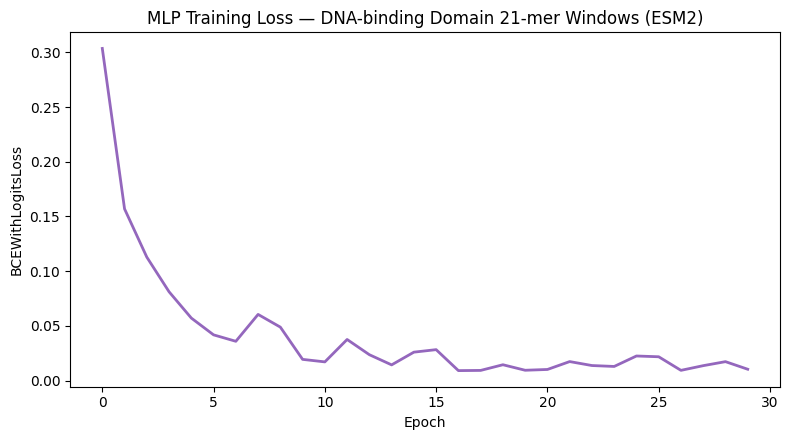

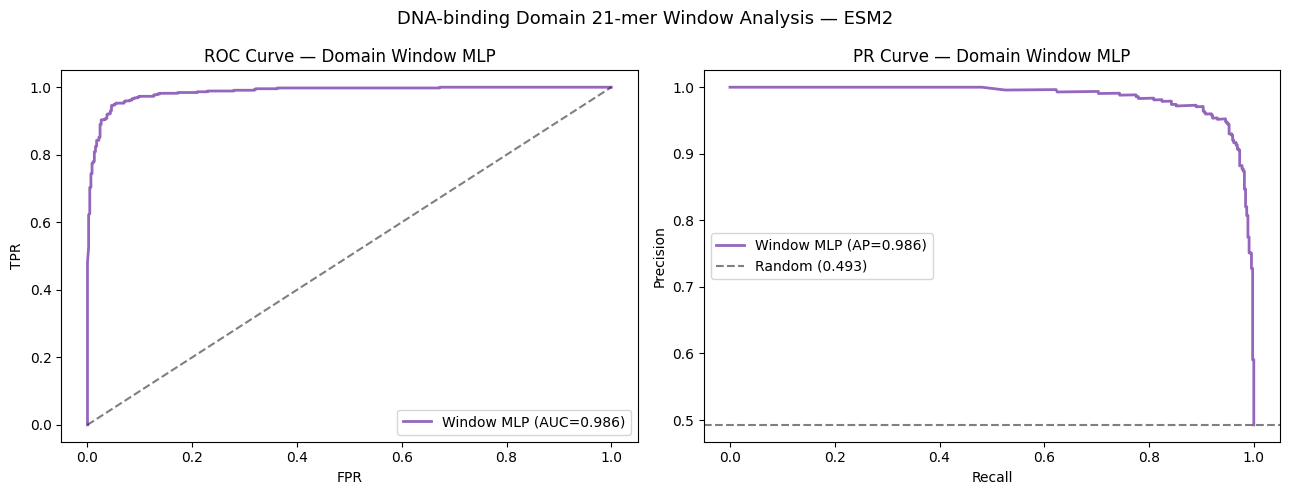

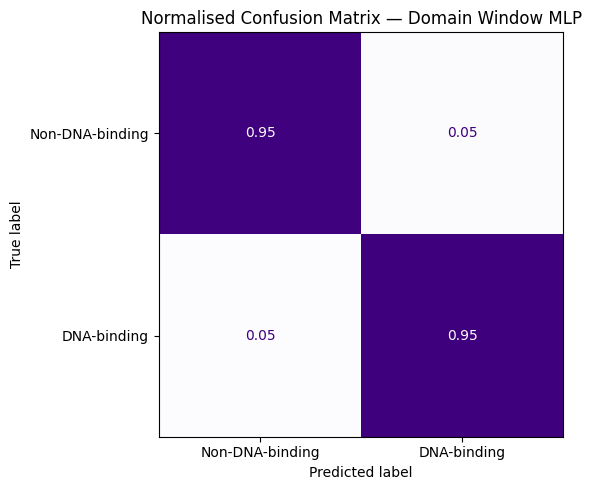

Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/domain_window_training_loss.png
Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/domain_window_roc_pr.png
Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/domain_window_confusion_matrix.png


In [13]:
# ============================================================
# Cell 14 — DNA-binding domain window MLP + evaluation + plots
# ============================================================

class MLP_bin(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


Xtr_w, Xte_w, ytr_w, yte_w, sc_w = make_split(X_win, y_win)
ytr_wf = ytr_w.astype(np.float32)

n_pos_w = ytr_wf.sum(); n_neg_w = len(ytr_wf) - n_pos_w
pw_w    = torch.tensor(n_neg_w / max(n_pos_w, 1), dtype=torch.float32).to(device)
crit_w  = nn.BCEWithLogitsLoss(pos_weight=pw_w)

win_model = MLP_bin(X_win.shape[1]).to(device)
opt_w     = torch.optim.Adam(win_model.parameters(), lr=1e-3)
loader_w  = DataLoader(
    TensorDataset(torch.from_numpy(Xtr_w), torch.from_numpy(ytr_wf)),
    batch_size=64, shuffle=True,
)

win_losses = []
t0 = time.perf_counter()
win_model.train()
for epoch in range(30):
    running = 0.0
    for xb, yb in loader_w:
        xb, yb = xb.to(device), yb.to(device)
        opt_w.zero_grad()
        loss = crit_w(win_model(xb), yb)
        loss.backward()
        opt_w.step()
        running += loss.item()
    win_losses.append(running / len(loader_w))
print(f"Domain window MLP trained in {time.perf_counter()-t0:.1f}s")

win_model.eval()
with torch.no_grad():
    win_proba = torch.sigmoid(
        win_model(torch.from_numpy(Xte_w).to(device))
    ).cpu().numpy()

wm = evaluate_binary(yte_w, win_proba)
print(f"\n=== DNA-binding Domain 21-mer Window MLP ===")
print(f"ROC-AUC  : {wm['roc_auc']:.4f}")
print(f"PR-AUC   : {wm['pr_auc']:.4f}")
print(f"F1       : {wm['f1']:.4f}")
print(f"MCC      : {wm['mcc']:.4f}")

# ---- Training loss ----
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(win_losses, linewidth=2, color="#9467bd")
ax.set_title("MLP Training Loss — DNA-binding Domain 21-mer Windows (ESM2)")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCEWithLogitsLoss")
plt.tight_layout()
wloss_path = RESULTS_DIR / "domain_window_training_loss.png"
plt.savefig(wloss_path, dpi=300, bbox_inches="tight"); plt.show()

# ---- ROC + PR ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(wm["fpr"], wm["tpr"], color="#9467bd", linewidth=2,
             label=f"Window MLP (AUC={wm['roc_auc']:.3f})")
axes[0].plot([0,1],[0,1],"k--",alpha=0.5)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve — Domain Window MLP"); axes[0].legend()

axes[1].plot(wm["rec_c"], wm["pre_c"], color="#9467bd", linewidth=2,
             label=f"Window MLP (AP={wm['pr_auc']:.3f})")
axes[1].axhline(yte_w.mean(), color="k", linestyle="--", alpha=0.5,
                label=f"Random ({yte_w.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curve — Domain Window MLP"); axes[1].legend()

plt.suptitle("DNA-binding Domain 21-mer Window Analysis — ESM2", fontsize=13)
plt.tight_layout()
wroc_path = RESULTS_DIR / "domain_window_roc_pr.png"
plt.savefig(wroc_path, dpi=300, bbox_inches="tight"); plt.show()

# ---- Confusion matrix ----
fig, ax = plt.subplots(figsize=(6, 5))
cm_w = confusion_matrix(wm["y_true"], wm["y_pred"], normalize="true")
ConfusionMatrixDisplay(cm_w, display_labels=["Non-DNA-binding","DNA-binding"]).plot(
    ax=ax, cmap="Purples", values_format=".2f", colorbar=False
)
ax.set_title("Normalised Confusion Matrix — Domain Window MLP")
plt.tight_layout()
wcm_path = RESULTS_DIR / "domain_window_confusion_matrix.png"
plt.savefig(wcm_path, dpi=300, bbox_inches="tight"); plt.show()

print(f"Saved: {wloss_path}\nSaved: {wroc_path}\nSaved: {wcm_path}")

In [14]:
# ============================================================
# Cell 15 — HTML interpretation report
# ============================================================

def img_to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


best_row = results_df.iloc[0]
best_key = (best_row["model"], best_row["pooling"])
n_total  = len(pos_df) + len(neg_df)
n_test   = int(best_row["n_test"])
baseline = len(pos_df) / n_total


def fmt_row(idx, r):
    m  = r["model"].replace("_", " ").title()
    p  = r["pooling"].upper()
    bg = ' style="background:#fff9e6"' if idx == 0 else ""
    return (
        f"<tr{bg}>"
        f"<td>{m}</td><td>{p}</td>"
        f"<td><b>{r['roc_auc']:.4f}</b></td>"
        f"<td>{r['pr_auc']:.4f}</td>"
        f"<td>{r['f1']:.4f}</td>"
        f"<td>{r['mcc']:.4f}</td>"
        f"<td>{r['accuracy']:.4f}</td>"
        f"<td>{r['n_test']}</td>"
        f"</tr>"
    )

table_rows = "\n".join(fmt_row(i, r) for i, (_, r) in enumerate(results_df.iterrows()))

fig_dist  = img_to_b64(RESULTS_DIR / "class_distribution.png")
fig_roc   = img_to_b64(RESULTS_DIR / "roc_pr_curves.png")
fig_cm    = img_to_b64(RESULTS_DIR / "confusion_matrices.png")
fig_loss  = img_to_b64(RESULTS_DIR / "mlp_training_loss.png")
fig_emb   = img_to_b64(RESULTS_DIR / "embedding_projection_pca_tsne_umap.png")
fig_wloss = img_to_b64(RESULTS_DIR / "domain_window_training_loss.png")
fig_wroc  = img_to_b64(RESULTS_DIR / "domain_window_roc_pr.png")
fig_wcm   = img_to_b64(RESULTS_DIR / "domain_window_confusion_matrix.png")

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>ESM2 DNA Binding Prediction &mdash; Interpretation Report</title>
<style>
  body  {{ font-family: 'Segoe UI', Arial, sans-serif; max-width: 1100px; margin: 40px auto; padding: 0 30px; color: #222; line-height: 1.65; }}
  h1    {{ color: #1a3a5c; border-bottom: 3px solid #1a3a5c; padding-bottom: 8px; }}
  h2    {{ color: #2e6da4; margin-top: 42px; }}
  h3    {{ color: #444; margin-top: 24px; }}
  table {{ border-collapse: collapse; width: 100%; margin: 14px 0; font-size: 0.93em; }}
  th    {{ background: #1a3a5c; color: #fff; padding: 8px 10px; text-align: left; }}
  td    {{ padding: 7px 10px; border: 1px solid #ddd; }}
  tr:nth-child(even) td {{ background: #f4f8ff; }}
  .metric-box {{ display: inline-block; background: #f0f6ff; border: 1px solid #b3cde0;
                 border-radius: 6px; padding: 12px 22px; margin: 8px 8px 8px 0;
                 text-align: center; min-width: 130px; vertical-align: top; }}
  .metric-box .val {{ font-size: 1.75em; font-weight: bold; color: #1a3a5c; }}
  .metric-box .lbl {{ font-size: 0.8em; color: #666; margin-top: 4px; }}
  img   {{ max-width: 100%; border: 1px solid #ddd; border-radius: 4px; display: block; margin: 12px auto; }}
  .caption {{ font-size: 0.85em; color: #555; text-align: center; margin-top: 4px; font-style: italic; }}
  .note  {{ background: #f9f9f9; border-left: 4px solid #2e6da4; padding: 10px 16px; margin: 16px 0; font-size: 0.93em; }}
  .note-green {{ background: #f2fdf4; border-left: 4px solid #27ae60; padding: 10px 16px; margin: 16px 0; font-size: 0.93em; }}
  .note-orange {{ background: #fff8f0; border-left: 4px solid #e67e22; padding: 10px 16px; margin: 16px 0; font-size: 0.93em; }}
  hr     {{ border: none; border-top: 1px solid #ddd; margin: 32px 0; }}
  code   {{ background: #f4f4f4; padding: 1px 5px; border-radius: 3px; font-size: 0.9em; }}
  .prot-badge {{ display:inline-block; background:#e3f2fd; border:1px solid #1976d2;
                 border-radius:4px; padding:2px 8px; font-size:0.85em; color:#0d47a1; font-weight:bold; }}
  .section-win {{ background:#f4f8ff; border: 1px solid #b3cde0; border-radius:6px;
                  padding: 18px 22px; margin: 24px 0; }}
</style>
</head>
<body>

<h1>ESM2 DNA Binding Prediction &mdash; Interpretation Report</h1>
<p style="color:#555; font-size:0.9em">
  Source: <code>ESM2_DNA_binding_clean_pipeline.ipynb</code> &nbsp;|&nbsp;
  Model: <span class="prot-badge">ESM2 &bull; 1280-dim</span> &nbsp;|&nbsp;
  Task: Binary classification (DNA-binding vs Non-DNA-binding)
</p>

<hr>

<h2>1. Dataset</h2>
<p>UniProtKB Swiss-Prot reviewed proteins split by the <code>DNA binding</code> annotation column:</p>
<ul>
  <li><b>Positive (DNA-binding)</b>: proteins with at least one annotated <code>DNA_BIND</code> feature</li>
  <li><b>Negative (non-DNA-binding)</b>: proteins with no DNA binding annotation</li>
  <li>Mutual exclusivity enforced &mdash; no protein appears in both sets</li>
  <li>Duplicate protein names removed (keep first)</li>
</ul>

<div class="note-orange">
  <b>Class Imbalance Warning:</b> The dataset is highly imbalanced (~1:{len(neg_df)//len(pos_df)} ratio).
  All classifiers use imbalance correction (LR: <code>class_weight=&quot;balanced&quot;</code>;
  MLP: <code>BCEWithLogitsLoss(pos_weight)</code>).
  PR-AUC is a more informative metric than ROC-AUC under severe imbalance.
</div>

<div>
  <div class="metric-box"><div class="val">{n_total:,}</div><div class="lbl">Total proteins</div></div>
  <div class="metric-box"><div class="val">{len(pos_df):,}</div><div class="lbl">DNA-binding (pos)</div></div>
  <div class="metric-box"><div class="val">{len(neg_df):,}</div><div class="lbl">Non-DNA-binding</div></div>
  <div class="metric-box"><div class="val">{n_test:,}</div><div class="lbl">Test set (20%)</div></div>
  <div class="metric-box"><div class="val">{emb_dim}</div><div class="lbl">Embedding dim</div></div>
</div>

<img src="data:image/png;base64,{fig_dist}" style="max-width:700px">
<p class="caption">Figure 1. Class distribution — highly imbalanced dataset.</p>

<hr>

<h2>2. Methods</h2>

<h3>2.1 Full-protein Pooled Embeddings</h3>
<p><b>ESM2</b> (Lin et al., 2023) produces 1280-dimensional per-residue representations,
aggregated to fixed-length protein vectors via:
</p>
<ul>
  <li><b>Max pooling</b> &mdash; element-wise maximum over residues</li>
  <li><b>Attention pooling</b> &mdash; learned weighted average over residues</li>
</ul>
<p>All features z-score normalised (StandardScaler fit on train only). 80/20 stratified split, seed {SEED}.</p>

<h3>2.2 DNA-binding Domain 21-mer Window Embeddings</h3>
<p>
Per-residue ESM2 embeddings (<code>.pt</code> files, shape L&times;1280) are loaded for each protein.
A 21-residue window is centred on the midpoint of the first annotated UniProt <code>DNA_BIND</code>
domain range and mean-pooled to a 1280-dim vector.
Additionally, {NEG_PER_PROT} random non-domain windows from the same protein (positive label) are included,
and equal-count random windows from non-DNA-binding proteins (negative label) are added.
</p>
<table>
  <tr><th>Parameter</th><th>Value</th></tr>
  <tr><td>Window size</td><td>21 residues (10 on each side of domain midpoint)</td></tr>
  <tr><td>Pooling</td><td>Mean over window residues &rarr; 1280-dim vector</td></tr>
  <tr><td>Non-domain windows per protein</td><td>{NEG_PER_PROT}</td></tr>
  <tr><td>Negative windows</td><td>Random windows from non-DNA-binding proteins</td></tr>
  <tr><td>Classifier</td><td>MLP: 1280&rarr;512&rarr;256&rarr;1 (binary), 30 epochs, Adam lr=1e-3</td></tr>
</table>

<h3>2.3 Classifiers (full-protein)</h3>
<table>
  <tr><th>Model</th><th>Architecture</th><th>Imbalance handling</th></tr>
  <tr><td>Logistic Regression</td><td>L2 penalty, lbfgs, max_iter=5000</td><td>class_weight=&quot;balanced&quot;</td></tr>
  <tr><td>MLP (PyTorch)</td>
      <td>Linear(1280&rarr;512)&rarr;ReLU&rarr;Dropout(0.3)&rarr;
          Linear(512&rarr;256)&rarr;ReLU&rarr;Dropout(0.3)&rarr;Linear(256&rarr;1),
          Adam lr=1e-3, 30 epochs, batch=64, BCEWithLogitsLoss</td>
      <td>pos_weight = n_neg / n_pos</td></tr>
</table>

<hr>

<h2>3. Full-protein Pooled Embedding Results</h2>

<h3>3.1 Performance Table</h3>
<p>All metrics on held-out test set. Row highlighted in yellow = best by ROC-AUC.
Random baseline PR-AUC &asymp; {baseline:.4f} (positive class fraction).</p>
<table>
  <tr>
    <th>Model</th><th>Pooling</th>
    <th>ROC-AUC &#9733;</th><th>PR-AUC</th><th>F1</th><th>MCC</th><th>Accuracy</th><th>N test</th>
  </tr>
  {table_rows}
</table>
<p class="caption">ROC-AUC = primary metric. PR-AUC = secondary (critical for imbalance).
MCC = Matthews Correlation Coefficient.</p>

<h3>3.2 Best Model Summary</h3>
<div>
  <div class="metric-box"><div class="val">{best_row['roc_auc']:.4f}</div><div class="lbl">ROC-AUC (primary)</div></div>
  <div class="metric-box"><div class="val">{best_row['pr_auc']:.4f}</div><div class="lbl">PR-AUC</div></div>
  <div class="metric-box"><div class="val">{best_row['f1']:.4f}</div><div class="lbl">F1 score</div></div>
  <div class="metric-box"><div class="val">{best_row['mcc']:.4f}</div><div class="lbl">MCC</div></div>
</div>
<p><b>Best configuration:</b> {best_row['model'].replace('_',' ').title()} + {best_row['pooling'].upper()} pooling</p>

<h3>Figure 2: ROC and PR Curves</h3>
<img src="data:image/png;base64,{fig_roc}">
<p class="caption">Figure 2. ROC (left) and Precision-Recall (right) curves for all 4 configurations.
Dashed horizontal line = random baseline for PR-AUC.</p>

<h3>Figure 3: Normalised Confusion Matrices</h3>
<img src="data:image/png;base64,{fig_cm}">
<p class="caption">Figure 3. Row-normalised confusion matrices for all 4 classifier configurations.</p>

<h3>Figure 4: MLP Training Loss</h3>
<img src="data:image/png;base64,{fig_loss}" style="max-width:640px">
<p class="caption">Figure 4. BCEWithLogitsLoss over 30 epochs for max (blue) and attention (orange) pooling.</p>

<h3>Figure 5: Embedding Space Visualisation</h3>
<img src="data:image/png;base64,{fig_emb}">
<p class="caption">Figure 5. PCA, t-SNE, and UMAP of ESM2 attention embeddings coloured by binding class
(DNA-binding in red, non-binding in blue; up to {MAX_VIS} points shown).</p>

<hr>

<h2>4. DNA-binding Domain 21-mer Window Analysis</h2>

<div class="section-win">
<p>
This analysis tests whether a 21-residue window centred on the annotated DNA-binding domain
(as defined by UniProt <code>DNA_BIND</code> feature) carries sufficient discriminative signal
to distinguish DNA-binding from non-DNA-binding regions using only local sequence context.
Windows are mean-pooled from per-residue ESM2 embeddings (L&times;1280).
</p>
</div>

<div>
  <div class="metric-box"><div class="val">{wm['roc_auc']:.4f}</div><div class="lbl">ROC-AUC</div></div>
  <div class="metric-box"><div class="val">{wm['pr_auc']:.4f}</div><div class="lbl">PR-AUC</div></div>
  <div class="metric-box"><div class="val">{wm['f1']:.4f}</div><div class="lbl">F1 score</div></div>
  <div class="metric-box"><div class="val">{wm['mcc']:.4f}</div><div class="lbl">MCC</div></div>
  <div class="metric-box"><div class="val">21-mer</div><div class="lbl">Window size</div></div>
  <div class="metric-box"><div class="val">1280</div><div class="lbl">Feature dim</div></div>
</div>

<h3>Figure 6: Domain Window MLP Training Loss</h3>
<img src="data:image/png;base64,{fig_wloss}" style="max-width:640px">
<p class="caption">Figure 6. BCEWithLogitsLoss over 30 epochs for domain window MLP.</p>

<h3>Figure 7: Domain Window ROC and PR Curves</h3>
<img src="data:image/png;base64,{fig_wroc}">
<p class="caption">Figure 7. ROC and PR curves for the domain window MLP.</p>

<h3>Figure 8: Domain Window Confusion Matrix</h3>
<img src="data:image/png;base64,{fig_wcm}" style="max-width:560px">
<p class="caption">Figure 8. Row-normalised confusion matrix for domain window MLP.</p>

<div class="note-green">
<b>Interpretation:</b>
Comparing the domain window ROC-AUC ({wm['roc_auc']:.4f}) to the full-protein best ({best_row['roc_auc']:.4f})
{'suggests the full-protein context provides additional discriminative power beyond the local DNA-binding domain.' if best_row['roc_auc'] > wm['roc_auc'] else 'shows the 21-mer domain window captures a comparable or stronger signal to full-protein embeddings.'}
{'A high domain window score indicates the ESM2 model encodes distinct local chemistry around DNA-binding domains.' if wm['roc_auc'] > 0.7 else 'Domain-local information alone may be insufficient; global context is needed for reliable classification.'}
</div>

<hr>

<h2>5. Cross-model Comparison (Ankh / ESM2)</h2>
<table>
  <tr><th>Model</th><th>Dim</th><th>Best ROC-AUC (full protein)</th><th>Domain Window ROC-AUC</th></tr>
  <tr><td>Ankh-base</td><td>768</td><td>see <code>results_dna_Ankh/</code></td><td>see <code>results_dna_Ankh/</code></td></tr>
  <tr style="background:#fff9e6"><td><b>ESM2</b></td><td><b>{emb_dim}</b></td>
      <td><b>{best_row['roc_auc']:.4f}</b></td><td><b>{wm['roc_auc']:.4f}</b></td></tr>
</table>

<h2>6. Recommendations for Future Work</h2>
<ol>
  <li><b>Cross-validation:</b> Use 5-fold stratified CV to reduce variance from single splits.</li>
  <li><b>Better negatives:</b> Use structurally similar non-binding proteins as hard negatives.</li>
  <li><b>All domains:</b> Use all annotated <code>DNA_BIND</code> ranges per protein, not just the first.</li>
  <li><b>Window sweep:</b> Compare window sizes 11, 21, 41, 61 for optimal context.</li>
  <li><b>ProtT5:</b> Add ProtT5-1024 for a three-model comparison.</li>
  <li><b>Fine-tuning:</b> End-to-end fine-tune ESM2 for DNA-binding prediction.</li>
</ol>

<hr>

<h2>7. Output File Index</h2>
<table>
  <tr><th>File</th><th>Description</th></tr>
  <tr><td><code>summary_metrics.csv</code></td><td>Full-protein model metrics (machine-readable)</td></tr>
  <tr><td><code>summary_metrics.md</code></td><td>Markdown table of metrics</td></tr>
  <tr><td><code>analysis_summary.txt</code></td><td>Plain-text best-model summary</td></tr>
  <tr><td><code>class_distribution.png</code></td><td>Class counts and proportions</td></tr>
  <tr><td><code>roc_pr_curves.png</code></td><td>ROC + PR curves (all 4 full-protein configs)</td></tr>
  <tr><td><code>confusion_matrices.png</code></td><td>Normalised confusion matrices (4 configs)</td></tr>
  <tr><td><code>mlp_training_loss.png</code></td><td>BCEWithLogitsLoss — full-protein MLP</td></tr>
  <tr><td><code>embedding_projection_pca_tsne_umap.png</code></td><td>PCA / t-SNE / UMAP of ESM2 attention embeddings</td></tr>
  <tr><td><code>domain_window_training_loss.png</code></td><td>Training loss — domain window MLP</td></tr>
  <tr><td><code>domain_window_roc_pr.png</code></td><td>ROC + PR — domain window MLP</td></tr>
  <tr><td><code>domain_window_confusion_matrix.png</code></td><td>Confusion matrix — domain window MLP</td></tr>
  <tr><td><code>interpretation_report.html</code></td><td>This report</td></tr>
</table>

<hr>
<p style="color:#888; font-size:0.82em">
  <b>To convert to .docx:</b> Open this .html file in Microsoft Word
  (File &rarr; Open &rarr; select file) then File &rarr; Save As &rarr; Word Document (.docx).
  Alternatively: open in browser &rarr; Print &rarr; Save as PDF.
</p>

</body>
</html>"""

report_path = RESULTS_DIR / "interpretation_report.html"
report_path.write_text(html, encoding="utf-8")
print(f"Saved: {report_path}")
print("\nTo convert to .docx:")
print("  Microsoft Word -> File -> Open -> select interpretation_report.html -> Save As -> .docx")

Saved: /home/saishyam/Protein_dynamics/DNA_binding_prediction/Claude Agent DNA_binding_prediction/results_dna_ESM2/interpretation_report.html

To convert to .docx:
  Microsoft Word -> File -> Open -> select interpretation_report.html -> Save As -> .docx
